# Credit Risk Prediction

With the increasing adoption of credit cards and digital payment systems, accurate credit risk prediction is essential to manage default risk and promote responsible lending. This study investigates credit default prediction using the Default of Credit Card Clients dataset from the UCI Machine Learning Repository (UCI, 2016). Rather than focusing solely on model accuracy, this work examines how preprocessing choices, feature engineering, and probability calibration affect predictive performance and decision quality.

### Objective
The objective is to analyze how different modeling decisions influence both classification outcomes and probability estimates, which are significant in real-world credit risk assessment. 

### Research Questions
1. How do repayment-status encoding choices affect model performance and calibration?
2. Do engineered behavioral features improve prediction beyond raw variables?
3. Can probability calibration and threshold tuning improve decision-making performance?

### Task Definition and Justification
Predict **default payment next month** based on demographic, credit limit, repayment status, billing amounts, and payment history features.

As fellow Filipinos, accurately predicting default risk is important because it ensures fairer access to credit for Filipino consumers by enabling more accurate risk-based decisions rather than overly restrictive lending policies. Furthermore, this helps banks and lending institutions manage credit card card usage and minimize financial losses in a rapidly growing digital payment environment.





## Dataset Description

This project uses the **Default of Credit Card Clients Dataset** from the UCI Machine Learning Repository. The dataset contains information on credit card clients and their payment behavior, and it is commonly used for credit risk prediction tasks.

The dataset contains **30,000 observations** with **24 attributes** (23 features, 1 target variable). The attributes are as following:

`X1` or `LIMIT_BAL`: Amount of the given credit (NT dollar), including both the individual consumer credit and his/her family (supplementary credit)

`X2` or `SEX`: Gender of the client (1 = male; 2 = female)

`X3` or `EDUCATION`: Education level (1 = graduate school; 2 = university; 3 = high school; 4 = others)

`X4` or `MARRIAGE`: Marital status (1 = married; 2 = single; 3 = others)

`X5` or `AGE`: Age in years

`X6 - X11` represents the history of past payments from April to September of 2005

| Value | Meaning |
|-------|---------|
| -2    | No consumption |
| -1    | Paid duly |
| 0     | Use of revolving credit |
| 1     | Payment delayed 1 month |
| 2     | Payment delayed 2 months |
| 3     | Payment delayed 3 months |
| 4     | Payment delayed 4 months |
| 5     | Payment delayed 5 months |
| 6     | Payment delayed 6 months |
| 7     | Payment delayed 7 months |
| 8     | Payment delayed 8 months |
| 9     | Payment delayed 9 months or more |

`X6` or `PAY_0`: Repayment status in September 2005

`X7` or `PAY_2`: Repayment status in August 2005

`X8` or `PAY_3`: Repayment status in July 2005

`X9` or `PAY_4`: Repayment status in June 2005

`X10` or `PAY_5`: Repayment status in May 2005

`X11` or `PAY_6`: Repayment status in April 2005

`X12 - X17` represents the amount of bill statements (NT dollar) from April to September of 2005

`X12` or `BILL_AMT1`: Amount of bill statement in September 2005

`X13` or `BILL_AMT2`: Amount of bill statement in August 2005

`X14` or `BILL_AMT3`: Amount of bill statement in July 2005

`X15` or `BILL_AMT4`: Amount of bill statement in June 2005

`X16` or `BILL_AMT5`: Amount of bill statement in May 2005

`X17` or `BILL_AMT6`: Amount of bill statement in April 2005

`X18 - X23` represents the amount of previous payments (NT dollar) from April to September of 2005

`X18` or `PAY_AMT1`: Amount paid in September 2005

`X19` or `PAY_AMT2`: Amount paid in August 2005

`X20` or `PAY_AMT3`: Amount paid in July 2005

`X21` or `PAY_AMT4`: Amount paid in June 2005

`X22` or `PAY_AMT5`: Amount paid in May 2005

`X23` or `PAY_AMT6`: Amount paid in April 2005

`Y` or `default payment`: Indicates whether the client defaulted on the next payment (1 = yes; 0 = no)


This dataset originates from Taiwan and reflects credit behavior from a specific historical context. As such, results may not directly generalize to modern or region-specific credit systems.

Source: UCI Machine Learning Repository – Default of Credit Card Clients Dataset

https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients

## Experimental Protocol and Reproducibility

### Data Splitting
The dataset is divided into training, validation, and test sets. Stratified sampling is used on test sets to preserve the class distribution. It is ensured that the test set is held out and only used for final evaluation.

### Leakage Prevention
For all of the preprocessing steps, including scaling and encoding, it is ensured that they are only fitted on training data and applied to validation and test sets so that data leakage is prevented.

### Evaluation Metrics
The model performance is evaluated using the following:
- Precision-Recall AUC (primary metric for imbalanced classification)
- ROC-AUC
- F1-score
- Brier Score (for probability calibration)
- Confusion Matrix (for decision analysis)

### Experimental Design
These are the three main experiments that are conducted:
1. Repayment-status encoding ablation
2. Feature engineering and feature-group ablation
3. Probability calibration and decision threshold optimization

Each experiment reports both quantitative results and interpretive insights.

## Data Preparation

### Imports

In [190]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, RandomizedSearchCV
)
from sklearn.metrics import (
    average_precision_score, roc_auc_score, brier_score_loss,
    precision_recall_curve, roc_curve, confusion_matrix, f1_score,
    classification_report, make_scorer, get_scorer
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from scipy.stats import randint, uniform

import shap

### Data Loading and Cleaning

We load the dataset from the `.xls` file using **pandas**, setting `header=1` to correctly read the column names from the second row.

In [191]:
df = pd.read_excel("default_of_credit_card_clients.xls", header=1)
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0



Then we must check for and remove duplicate rows before dropping the ID column. This needs to be done because two distinct clients with identical feature values would be treated as duplicates if we drop the ID column first, reducing the dataset below the canonical 30,000 documented instances.
We will drop the `ID` column since it is a unique identifier for each client and does not provide predictive information.

In [192]:
print(f"Duplicate rows (before dropping ID): {df.duplicated().sum()}")
df = df.drop_duplicates()
df = df.drop("ID", axis=1)
print(f"Rows after deduplication: {len(df)}")
df.head()

Duplicate rows (before dropping ID): 0
Rows after deduplication: 30000


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


### Data Integrity Check
It has been verified that the dataset actually matches the dimensions of 30,000 instances and 25 features, 24 after removing the ID column. 

In [193]:
print(f"Dataset shape: {df.shape}")
assert df.shape[0] == 30000, (
    f"WARNING: Expected 30,000 rows, got {df.shape[0]}. "
)
assert df.shape[1] == 24, (
    f"WARNING: Expected 24 columns after dropping ID, got {df.shape[1]}."
)
print("Dataset integrity confirmation: 30,000 instances, 24 features.")

Dataset shape: (30000, 24)
Dataset integrity confirmation: 30,000 instances, 24 features.


## Exploratory Data Analysis (EDA)

We will perform EDA to understand feature distributions, correlations, detect missing values, and identify any irregularities in the dataset.

`df.describe()` allows us to view Summary statistics.

In [194]:
df.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


`df.info()` allows us to view the high level information of the dataset.

In [195]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BILL_AMT2                   30000 non-null  int64
 13  BILL_AMT3                   30000 non-null  int64
 14  BILL_A

With this, we can see that there are no missing values as all columns have the correct number (30,000) of non-null entries

Class distribution:
default payment next month
0    23364
1     6636
Name: count, dtype: int64


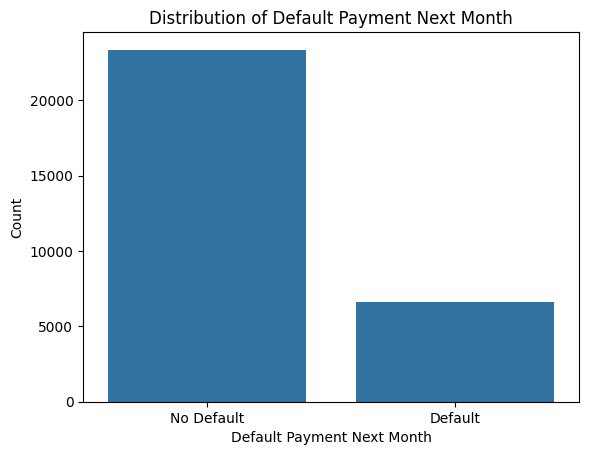

In [196]:
print("Class distribution:")
print(df['default payment next month'].value_counts())

sns.countplot(x='default payment next month', data=df)
plt.title('Distribution of Default Payment Next Month')
plt.xlabel('Default Payment Next Month')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Default', 'Default'])
plt.show()

We observe a moderate class imbalance in the target variable, with a ratio of approximately 3.5:1 between non-default and default cases. To mitigate potential bias toward the majority class, we will apply stratified splitting in the train-test split and class weighting during model training.

Let's create a correlation heatmap of the entire dataset to get a general overview of the data.

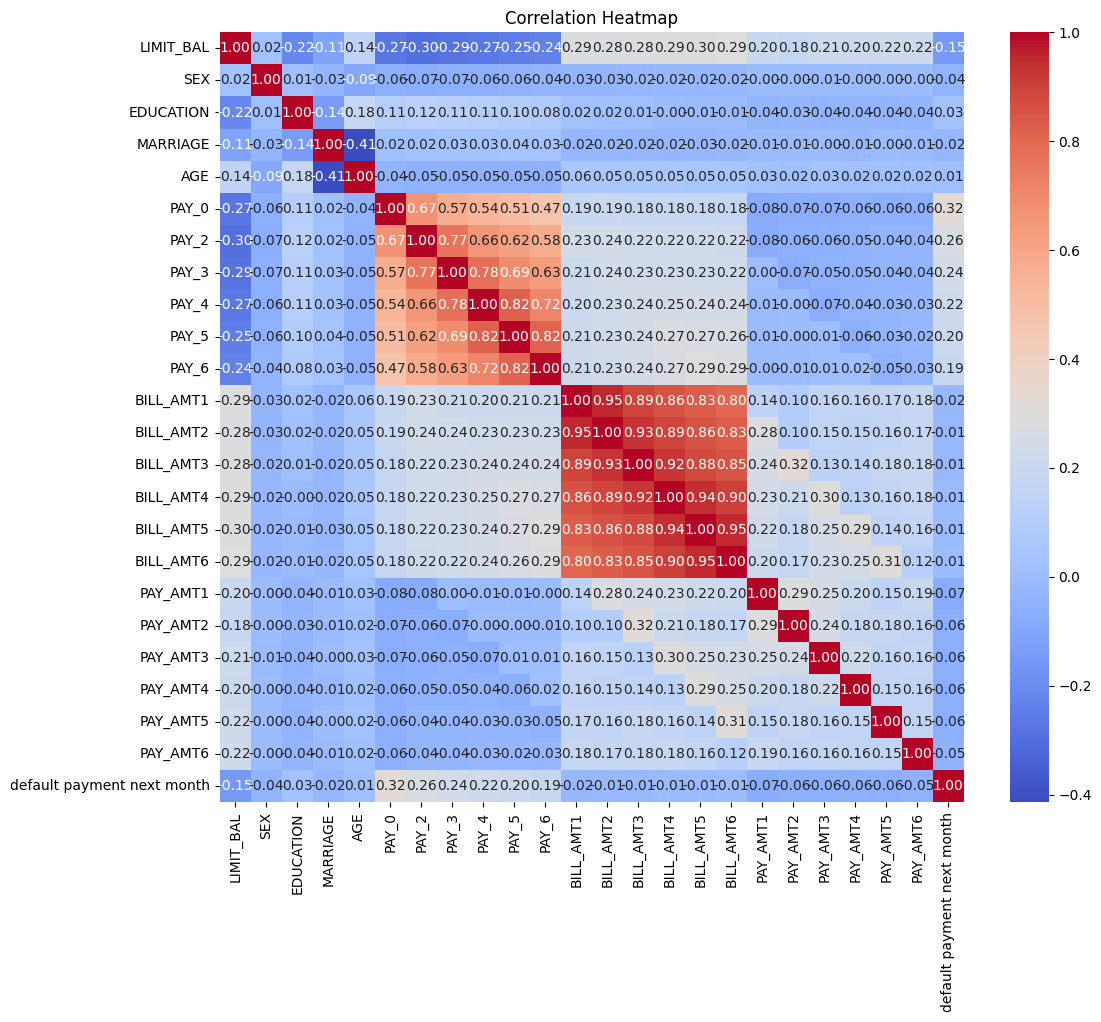

In [197]:
df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap reveals that the repayment status variables (`PAY_0` - `PAY_6`) exhibit the strongest positive correlations with the target variable, indicating that delayed repayments increase the likelihood of default. The correlations are decreasing for older repayment months, suggesting that more recent repayment behavior is a stronger predictor of default risk. We can also see strong correlation among all repayment status variables, which may suggest that clients' repayment behavior is consistent over time.

Billing amounts (`BILL-AMT1` - `BILL_AMT6`) are strongly correlated with each other, reflecting consistent spending patterns, but show minimal correlation with default. Payment amounts and demographic variables also show weak relationships with default.

Credit limit (`LIMIT_BAL`) has a weak negative relationship with default, which suggests that higher credit limits may be associated with slightly lower default probability. We can use a boxplot to visualize this more clearly.

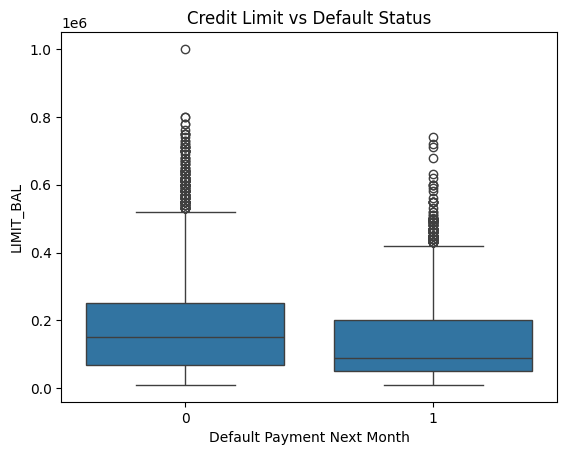

In [198]:
sns.boxplot(x='default payment next month', y='LIMIT_BAL', data=df)
plt.title("Credit Limit vs Default Status")
plt.xlabel("Default Payment Next Month")
plt.ylabel("LIMIT_BAL")
plt.show()

This boxplot suggests that clients who default tend to have lower credit limits compared to non-default clients. Credit limit alone is not a strong predictor of default because of a significant overlap between the two groups. The outliers in both groups represent a wide range of credit limits. It can be observed from the boxplot that non-defaulters seem to have more extreme values with their outliers.

### Figure A1: Default Rate by PAY_0 State

We should visualize the default rate across each documented PAY_0 repayment status value before running the experiments. If the default rate differs meaningfully across the states -2, -1, 0, 1...9, then merging those states would destroy the discriminative signal. The choice must be tested as a hypothesis rather than assumed to be correct. It is the semantic sanity check for experiment A. We need to check if the PAY_0 values actually mean different risk levels before we start changing them.

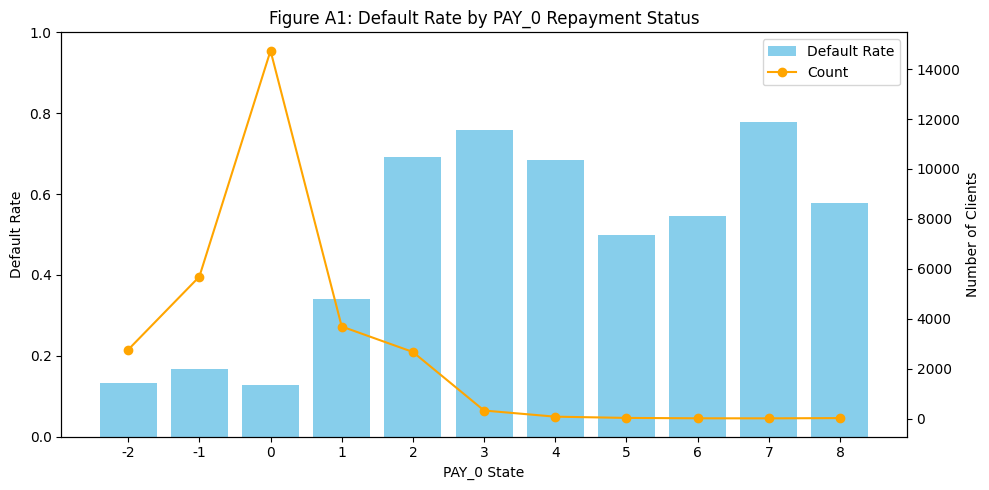

In [199]:
pay0_default_rate = (
    df.groupby("PAY_0")["default payment next month"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "Default Rate", "count": "Count"})
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax2 = ax1.twinx()

ax1.bar(
    pay0_default_rate["PAY_0"].astype(str),
    pay0_default_rate["Default Rate"],
    label="Default Rate",
    color="skyblue"
)

ax2.plot(
    pay0_default_rate["PAY_0"].astype(str),
    pay0_default_rate["Count"],
    marker="o",
    label="Count",
    color="orange",
)

ax1.set_xlabel("PAY_0 State")
ax1.set_ylabel("Default Rate")
ax2.set_ylabel("Number of Clients")
ax1.set_title("Figure A1: Default Rate by PAY_0 Repayment Status")
ax1.set_ylim(0, 1)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.tight_layout()
plt.savefig("fig_A1_pay0_default_rate.png", dpi=150)
plt.show()

The default rates across the states -2, -1, and 0 are relatively similar, with -1 being slightly higher. This suggests that they may represent a common risk level. We can also see that the different between states 0 and 1+ are large. Therefore, we can hypothesize that merging states -2, -1, and 0 into a single category of "no delay" will not significantly reduce predictive performance.

## Model Selection and Training

To predict the probability of a client to default on their credit card payment, we will first train both a **Logistic Regression** and a **Histogram-based Gradient Boosting** model. 

Logistic Regression is commonly used as a baseline model for binary classification tasks due to its interpretability and efficiency. Instead of only predicting whether a client will default or not, the model can also estimate the **probability of default** for each client. Predicting probabilities provides more detailed information about the level of risk associated with each client.

However, logistic regression may not be able to capture complex patterns in the data due to its assumption of a linear relationship. To address this, a **Histogram-based Gradient Boosting** model is also evaluated. This is used to capture non-linear relationships and feature interactions that linear models cannot represent. ***insert info about HGB and why it's good for this***

Due to the class imbalance (approximately 3.5:1 ratio), we will implement the following strategies as stated previously:

1. **Stratified Train-Test Split**

2. **Class Weighting**

A stratified train-test split will ensure that both the train and test data maintain the same class distribution. We will also apply a higher weight to the minority class (default cases) to reduce bias towards predicting the majority class. 
*insert info about the split (70-10-20)*


In [200]:
from sklearn.model_selection import train_test_split

X = df.drop("default payment next month", axis=1)
y = df["default payment next month"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, stratify=y_train, random_state=42)


print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (21600, 23)
y_train shape: (21600,)
X_val shape: (2400, 23)
y_val shape: (2400,)
X_test shape: (6000, 23)
y_test shape: (6000,)


#### PAY Encoding

We will test three encoding strategies to identify which will have the best performance. They are as follows:
- V1: Keep all states as-is
- V2: Merge -2, -1, and 0 into one state
- V3: Treat PAY states as string categories for linear models

We will create functions for each variant to be used and apply them to each set.

In [201]:
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

def pay_v1(X):
    return X.copy()

def pay_v2(X):
    X = X.copy()
    X[pay_cols] = X[pay_cols].replace([-2, -1], 0)
    return X

def pay_v3(X):
    X = X.copy()
    for col in pay_cols:
        X[col] = X[col].astype(str)
    return X

#### Feature Engineering

Feature engineering is performed to capture temporal and behavioral patterns in repayment history and financial activity that may not be fully represented by the original variables. These will be integrated later into the pipeline and done after splitting to avoid leakage.

The engineered features include:
- `avg_pay_delay`: mean payment delay
- `max_delay`: captures the most extreme repayment behavior
- `num_late`: frequency of delayed payments
- `avg_bill`: mean bill statement amount
- `avg_paid`: mean payment amount
- `avg_pay_ratio`: ratio of payment amount to bill amount, how much of the outstanding balance is repaid on average

In [202]:
bill_cols = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]
payamt_cols = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]

def add_features(X):
    X = X.copy()
    pay_numeric = X[pay_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

    X["avg_pay_delay"] = pay_numeric.mean(axis=1)
    X["max_delay"] = pay_numeric.max(axis=1)
    X["num_late"] = (pay_numeric > 0).sum(axis=1)
    X["avg_bill"] = X[bill_cols].mean(axis=1)
    X["avg_paid"] = X[payamt_cols].mean(axis=1)

    bill_pos = X[bill_cols].clip(lower=0)
    monthly_ratios = X[payamt_cols].values / (bill_pos.values + 1)
    X["avg_pay_ratio"] = np.clip(monthly_ratios, 0, 5).mean(axis=1)
    return X

### Pipeline Definition

We will create pipelines for both models to prevent leakage and ensure all transforms are learned only from training data. 

Let us first build a ColumnTransformer to handle the one-hot encoding of categorical columns and the standardization of numerical columns.

In [203]:
DEFAULT_CAT_COLS = ["SEX", "EDUCATION", "MARRIAGE"]
DEFAULT_NUM_COLS = ["LIMIT_BAL", "AGE"] + bill_cols + payamt_cols

def build_preprocessor(cat_cols, num_cols):
    transformers = [
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
    ]

    # remainder="passthrough" ensures that any columns not specified in transformers are included in the output without transformation
    return ColumnTransformer(transformers=transformers, remainder="passthrough")


Let us build pipelines for both models.

We will use `class_weight="balanced"` for both models to handle the class imbalance as it automatically adjusts the weights based on the class frequencies.

The max iterations are set to ensure that the models fully converge and avoid warnings or premature stops. We set `random_state=42` to have consistent estimation and performance for comparability.

For `HistGradientBoostingClassifier`, we enable **early stopping** to reduce overfitting and improve generalization by preventing unnecessary boosting iterations once the model has converged. `validation_fraction` is the proportion of training data set aside as a validation set for early stopping. `n_iter_no_change` determines when to early stop if the validation score does not improve for n consecutive iterations.

In [236]:
def build_lr_pipeline(cat_cols, num_cols):
    preprocessor = build_preprocessor(cat_cols, num_cols)
    return Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42, C=1.0))
    ])

def build_hgb_pipeline(cat_cols, num_cols):
    preprocessor = build_preprocessor(cat_cols, num_cols)
    return Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", HistGradientBoostingClassifier(
            max_iter=1000,
            class_weight="balanced",
            random_state=42,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=10
        ))
    ])

#### Cross-Validated Evaluation Function

We create a reusable evaluation function to reduce redundancy. With `StratifiedKFold`, we will use a 5-fold stratified cross-validation in all experiments. This preserves the class proportions in each fold and ensures no leakage as all preprocessing inside the pipeline is refitted per fold.

The following evaluation metrics are used:
- Brier Score
    - Measures the mean squared error between predicted probabilities and actual binary outcomes. Smaller scores (closer to 0) indicate better calibrated and more accurate probability predictions, while scores in the middle (close to 0.5) can be hard to interpret as either "good" or "bad."
- ROC-AUC
    - Measures how well the model separates the positive cases from the negative cases across all thresholds. While ROC-AUC remains a useful metric for evaluating ranking performance across thresholds, it may be optimistic in imbalanced settings. 
    - A high AUC (close to 1) means that the model effectively distinguishes between the positive and negative classes, a low AUC (close to 0) indicates that the model struggles to differentiate the two classes, and an AUC around 0.5 suggests that the model does not learn any meaningful patterns and is doing random guessing.
- Precision-Recall AUC
    - Evaluates how well the model identifies the positive class (default). It is particulary useful in this case, where we have a 3.5:1 ratio of non-default to default cases, since it focuses on the minority class. A higher AUC typically indicates better model performance.
- F1-Score
    - Used to evaluate how well a classification model performs by combining precision and recall using the harmonic mean.

In [237]:
brier_scorer = get_scorer("neg_brier_score")
pr_auc_scorer = get_scorer("average_precision")
roc_auc_scorer = get_scorer("roc_auc")
f1_scorer = get_scorer("f1")

CV_METRICS = {
    "Brier_Score": brier_scorer,
    "PR_AUC": pr_auc_scorer,
    "ROC_AUC": roc_auc_scorer,
    "F1": f1_scorer
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_pipeline(pipeline, X, y, label="Model"):
    results = cross_validate(
        pipeline, X, y,
        cv=skf,
        scoring=CV_METRICS,
        return_train_score=False,
        n_jobs=-1
    )

    print(f"{label} Cross-Validation Results:")
    for metric_name, scores in results.items():
        mean = scores.mean()
        std = scores.std()
        if metric_name == "test_Brier_Score":
            mean = -mean  # Convert back to positive Brier Score
        print(f" {metric_name}: {mean:.4f} ± {std:.4f}")

    return {
        "label": label,
        "brier_score": -results["test_Brier_Score"].mean(),
        "pr_auc": results["test_PR_AUC"].mean(),
        "roc_auc": results["test_ROC_AUC"].mean(),
        "f1": results["test_F1"].mean()
    }

### Experiment A: PAY Encoding Ablation

For this experiment, our hypotheses are:
- Encoding choices for repayment status columns (`PAY_0`-`PAY_6`) affect both discrimination (PR-AUC) and probability quality (Brier Score)
- Collapsing states will outperform preserving repayment semantics

We will use the variants created previously:
- V1: States kept as-is
- V2: Merged -2 and -1 into 0
- V3: States treated as categories

We will test this on both models using only the raw features, meaning we will not apply feature engineering yet.

Since this is a feature design experiment, we will concatenate the training and validation set to have more data and more stable metrics.

In [238]:
# Combine training and validation sets, reset_index to ensure clean indices for modeling
X_trainval = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_trainval = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

results_A = []

for variant_name, X_tv, pay_cat in [
    ("V1 (As-is)", X_trainval, False),
    ("V2 (Merged -2,-1 → 0)", pay_v2(X_trainval), False),
    ("V3 (Categorical)", pay_v3(X_trainval), True)
]:
    for model_name, build_pipeline in [
        ("Logistic Regression", build_lr_pipeline),
        ("HistGradientBoosting", build_hgb_pipeline)
    ]:
        print(f"Evaluating {model_name} with {variant_name}...")
        if pay_cat:
            cat_cols = DEFAULT_CAT_COLS + pay_cols
            num_cols = DEFAULT_NUM_COLS
        else:
            cat_cols = DEFAULT_CAT_COLS
            num_cols = DEFAULT_NUM_COLS + pay_cols
        pipeline = build_pipeline(cat_cols, num_cols)
        result = evaluate_pipeline(pipeline, X_tv, y_trainval, label=f"{model_name} - {variant_name}")
        results_A.append(result)

Evaluating Logistic Regression with V1 (As-is)...
Logistic Regression - V1 (As-is) Cross-Validation Results:
 fit_time: 0.2276 ± 0.0118
 score_time: 0.0339 ± 0.0020
 test_Brier_Score: 0.2056 ± 0.0028
 test_PR_AUC: 0.5062 ± 0.0199
 test_ROC_AUC: 0.7283 ± 0.0077
 test_F1: 0.4793 ± 0.0070
Evaluating HistGradientBoosting with V1 (As-is)...
HistGradientBoosting - V1 (As-is) Cross-Validation Results:
 fit_time: 0.5181 ± 0.0725
 score_time: 0.1100 ± 0.0123
 test_Brier_Score: 0.1762 ± 0.0039
 test_PR_AUC: 0.5543 ± 0.0221
 test_ROC_AUC: 0.7813 ± 0.0088
 test_F1: 0.5380 ± 0.0110
Evaluating Logistic Regression with V2 (Merged -2,-1 → 0)...
Logistic Regression - V2 (Merged -2,-1 → 0) Cross-Validation Results:
 fit_time: 0.2883 ± 0.0070
 score_time: 0.0364 ± 0.0036
 test_Brier_Score: 0.1865 ± 0.0040
 test_PR_AUC: 0.5318 ± 0.0203
 test_ROC_AUC: 0.7645 ± 0.0120
 test_F1: 0.5319 ± 0.0168
Evaluating HistGradientBoosting with V2 (Merged -2,-1 → 0)...
HistGradientBoosting - V2 (Merged -2,-1 → 0) Cross-Va

Let's create graphs to visualize the results more clearly.

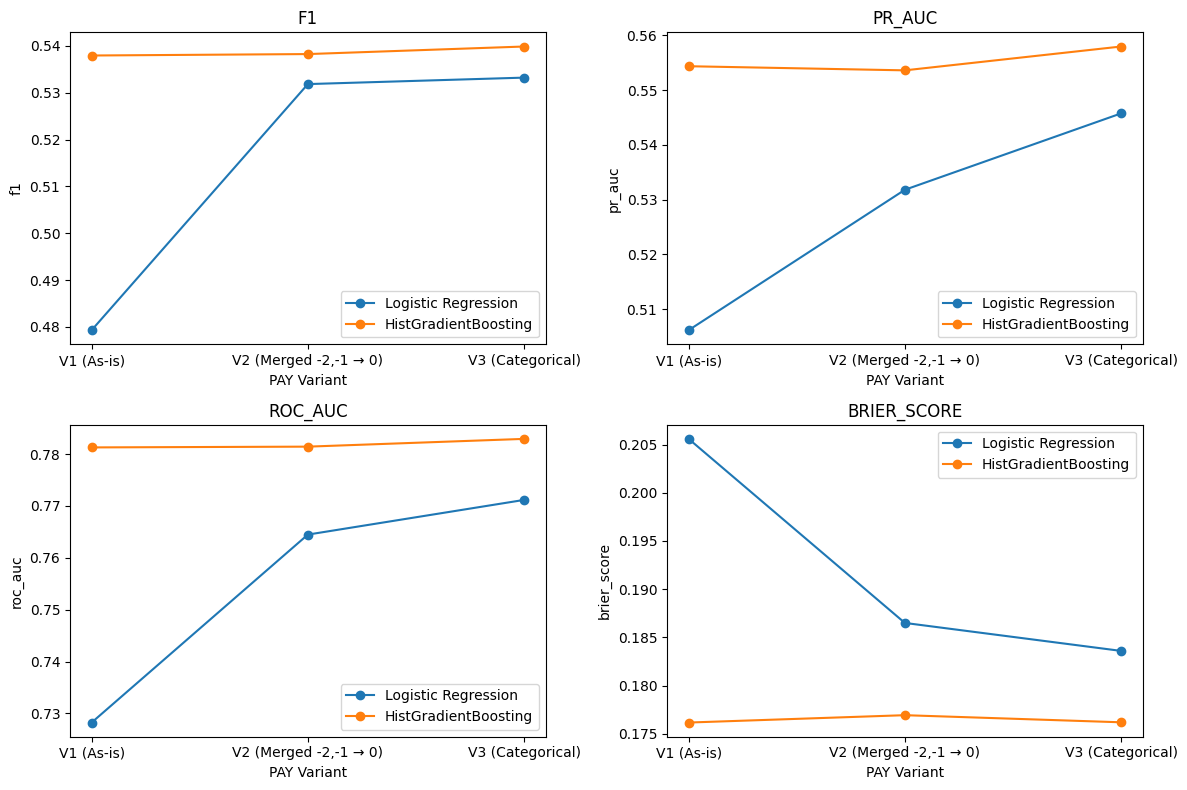

Best variant per model based on combined score:
                  model           variant     score
5  HistGradientBoosting  V3 (Categorical)  1.164671
4   Logistic Regression  V3 (Categorical)  1.133296


In [239]:
df_A = pd.DataFrame(results_A)

df_A["model"] = df_A["label"].apply(lambda x: x.split(" - ")[0])
df_A["variant"] = df_A["label"].apply(lambda x: x.split(" - ")[-1])

order = [
    "V1 (As-is)",
    "V2 (Merged -2,-1 → 0)",
    "V3 (Categorical)"
]

df_plot = df_A.copy()

df_plot["variant"] = pd.Categorical(df_plot["variant"], categories=order, ordered=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

metric_list = ["f1", "pr_auc", "roc_auc", "brier_score"]

for ax, metric in zip(axes.flat, metric_list):

    for model in df_plot["model"].unique():
        subset = df_plot[df_plot["model"] == model].sort_values("variant")

        ax.plot(
            subset["variant"],
            subset[metric],
            marker="o",
            label=model
        )

    ax.set_title(metric.upper())
    ax.set_xlabel("PAY Variant")
    ax.set_ylabel(metric)
    ax.legend()

plt.tight_layout()
plt.show()


df_A["score"] = (
    df_A["pr_auc"]
    + df_A["roc_auc"]
    - df_A["brier_score"]
)

best_per_model = df_A.loc[
    df_A.groupby("model")["score"].idxmax()
]
print("Best variant per model based on combined score:")
print(best_per_model[["model", "variant", "score"]])

We can see that the logistic regression model has a strong upward trend for F1, PR AUC, and ROC-AUC, and a downward trend for Brier Score. The HGB model has miniscule changes to the evaluation metrics. This suggests that feature encoding significantly affects the logistic regression model, but has minimal impact on the HGB model.

The categorical encoding of PAY variables (V3) consistently yields the highest discriminative performance on both models.

### Experiment B: Feature-Group Ablation
*insert explanation why we doin this*

For this experiment, our hypotheses are:
- Behavioral aggregates can capture more beyond the raw monthly variables
- Specific feature groups (repayment history vs amounts vs demographic) differ in predictive contribution

We will also implement the best PAY encoding from Experiment A: V3 (Categorical)

The feature sets are as follows:
| Label | Description |
|-------|-------------|
| F1    | Raw features|
| F2    | Raw features and engineered features |
| F3    | Repayment history features only |
| F4    | Billing and payment amounts only |
| F5    | Demographic information and credit limit only |

In [240]:
X_tv_best = pay_v3(X_trainval)
X_test_best = pay_v3(X_test)
pay_cat = True

X_tv_eng = add_features(X_tv_best)
eng_features = ["avg_pay_delay", "max_delay", "num_late", "avg_bill", "avg_paid", "avg_pay_ratio"]

FEATURE_SETS = {
    "F1 Raw": list(X_tv_best.columns),
    "F2 Raw + Engineered": list(X_tv_eng.columns),
    "F3 Repayments Only": pay_cols + ["avg_pay_delay", "max_delay", "num_late"],
    "F4 Amounts Only": bill_cols + payamt_cols + ["avg_bill", "avg_paid", "avg_pay_ratio"],
    "F5 Demographic + Limit Only": ["LIMIT_BAL", "AGE", "SEX", "EDUCATION", "MARRIAGE"]
}

results_B = []

cat_cols = DEFAULT_CAT_COLS + pay_cols

def get_num_cat_features(feature_list):
    num_feats = [f for f in feature_list if f not in cat_cols]
    cat_feats = [f for f in feature_list if f in cat_cols]
    return num_feats, cat_feats

for feature_set_name, features in FEATURE_SETS.items():
    X_subset = X_tv_eng[features].copy()

    num, cat = get_num_cat_features(features)

    for model_name, build_pipeline in [
        ("Logistic Regression", build_lr_pipeline),
        ("HistGradientBoosting", build_hgb_pipeline)
    ]:
        print(f"Evaluating {model_name} with {feature_set_name}...")
        pipeline = build_pipeline(cat, num)
        result = evaluate_pipeline(pipeline, X_subset, y_trainval, label=f"{model_name} - {feature_set_name}")
        results_B.append(result)

   

df_B = pd.DataFrame(results_B)
df_B["model"] = df_B["label"].apply(lambda x: x.split(" - ")[0])


Evaluating Logistic Regression with F1 Raw...
Logistic Regression - F1 Raw Cross-Validation Results:
 fit_time: 1.1073 ± 0.0708
 score_time: 0.0708 ± 0.0191
 test_Brier_Score: 0.1836 ± 0.0044
 test_PR_AUC: 0.5457 ± 0.0226
 test_ROC_AUC: 0.7712 ± 0.0128
 test_F1: 0.5332 ± 0.0177
Evaluating HistGradientBoosting with F1 Raw...
HistGradientBoosting - F1 Raw Cross-Validation Results:
 fit_time: 1.4537 ± 0.0778
 score_time: 0.2115 ± 0.0281
 test_Brier_Score: 0.1762 ± 0.0035
 test_PR_AUC: 0.5579 ± 0.0233
 test_ROC_AUC: 0.7829 ± 0.0086
 test_F1: 0.5399 ± 0.0156
Evaluating Logistic Regression with F2 Raw + Engineered...
Logistic Regression - F2 Raw + Engineered Cross-Validation Results:
 fit_time: 1.2260 ± 0.0678
 score_time: 0.0735 ± 0.0252
 test_Brier_Score: 0.1829 ± 0.0045
 test_PR_AUC: 0.5487 ± 0.0210
 test_ROC_AUC: 0.7754 ± 0.0123
 test_F1: 0.5329 ± 0.0196
Evaluating HistGradientBoosting with F2 Raw + Engineered...
HistGradientBoosting - F2 Raw + Engineered Cross-Validation Results:
 fit_t

Let's create graphs to visualize the results more clearly.

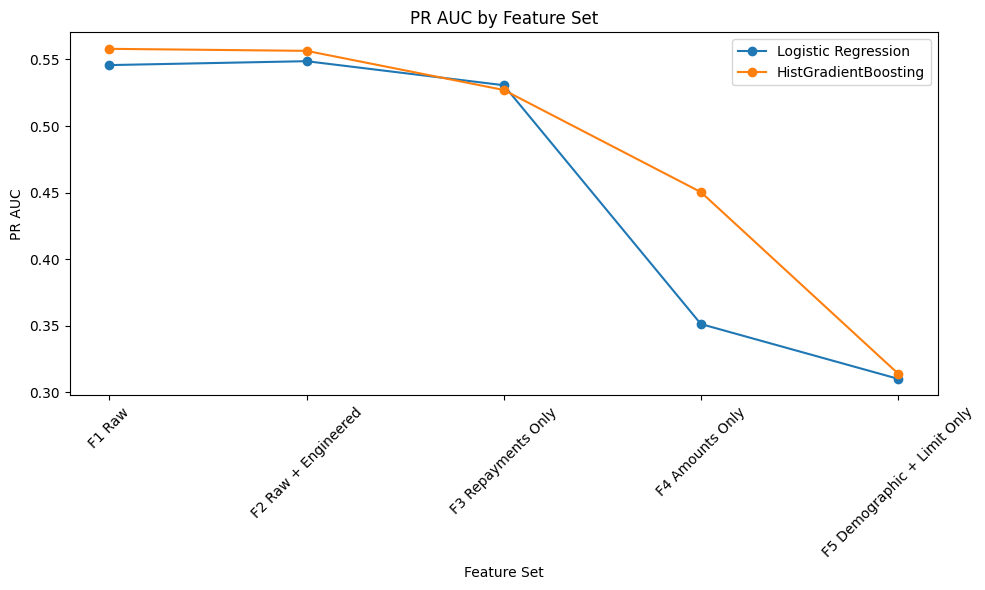

In [241]:
df_B["feature_set"] = df_B["label"].apply(lambda x: x.split(" - ")[-1])

plt.figure(figsize=(10, 6))
for model in df_B["model"].unique():
    subset = df_B[df_B["model"] == model].sort_values("feature_set")
    plt.plot(
        subset["feature_set"],
        subset["pr_auc"],
        marker="o",
        label=model,
    )
plt.title("PR AUC by Feature Set")
plt.xlabel("Feature Set")
plt.ylabel("PR AUC")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Both models show similar trends, except for the feature set with the raw and engineered features. The logistic regression model does better with the added engineered features, while the histogram-based gradient boosting model does better with just the raw features.

Among repayment history, amounts, and demographic feature groups, repayment history has the highest performance. This suggests that repayment history is the strongest single indicator of default risk. The demographic + limit feature set consistently performed the worst, indicating that these alone are weak indicators of default risk.

## Error Analysis and Model Tuning

### Hyperparameter Tuning

*justification for what metric to optimize (pr-auc)*

#### Parameters
*(put justification n stuff as to why), also put what each parameter is*

In [242]:
# just a placeholder for now
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", "log2", None]}

*RandomizedSearchCV*

## Model Evaluation

Sources

https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc

https://www.geeksforgeeks.org/machine-learning/auc-roc-curve/

# Final model interpretation

# Error Analysis

# Results Summary

# Limitations

# References